In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [3]:
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


In [5]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


In [6]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [7]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


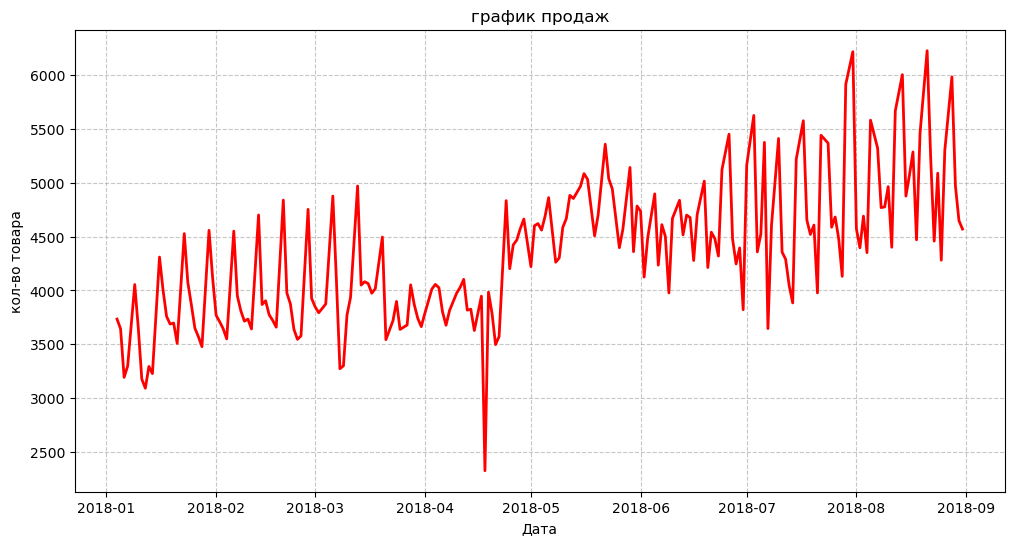

In [8]:
plt.figure(figsize = (12, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], color = 'red', linewidth = 2)
plt.title('график продаж')
plt.xlabel('Дата')
plt.ylabel('кол-во товара')
plt.grid(True, linestyle = '--', alpha=0.7)
plt.show()

In [9]:
#на графике продаж можно увидеть восходящий тренд: в начале года продажи находятся на минимуме. 
#А в конце графика можно увидеть продажи, которые заметно выросли и достигают своих пиков. 
#Можно сделать вывод: стабильный рост бизнеса в течении 8-9 месяцев
#Можно заметить что график имеет зигзаго образную структуру. То есть, это говорит о том что, были колебания в продажах и скорее всего это 
#связано с выходными. Но не смотря на это видно что график плотный без больших пробелов и были ежеденевные операции.
#Так же можно отметить резкие "взлеты" весной и пиковые результаты летом. 

In [10]:
max_sale_row = df[df['Количество'] == df['Количество'].max()]
print('cтрокa, у которой максимальный выброс по количеству продаж')
print(max_sale_row)

cтрокa, у которой максимальный выброс по количеству продаж
             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


In [11]:
summer_wednesday = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Дата'].dt.dayofweek == 2)]

In [12]:
top_tovar = summer_wednesday.groupby('Номенклатура')['Количество'].sum().sort_values(ascending = False).head(1)
print('топовый товар по продажам по средам за июнь, июль, август у 3 склада')
print(top_tovar)

топовый товар по продажам по средам за июнь, июль, август у 3 склада
Номенклатура
product_1    2267
Name: Количество, dtype: int64


In [13]:
weather_df = pd.read_csv('погода Астана архив.csv', comment = '#', sep=';', index_col = False)

In [14]:
weather_df.columns = weather_df.columns.str.replace('"', '')

In [15]:
for col in weather_df.select_dtypes(include=['object']):
    weather_df[col] = weather_df[col].str.replace('"', '')

In [16]:
print(weather_df.columns.tolist())

['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', "E'", 'sss']


In [17]:
weather_df['Местное время в Астане'] = pd.to_datetime(weather_df['Местное время в Астане'], dayfirst=True)

In [18]:
weather_df['T'] = pd.to_numeric(weather_df['T'], errors = 'coerce')

In [19]:
weather_df['Дата без времени'] = weather_df['Местное время в Астане'].dt.date

In [20]:
daily_weather = weather_df.groupby('Дата без времени')['T'].mean().reset_index()
daily_weather.columns = ['Дата', 'T']

In [21]:
daily_weather['Дата'] = pd.to_datetime(daily_weather['Дата'])
print(daily_weather.head())

        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625
3 2018-01-04 -14.0750
4 2018-01-05 -16.8625


In [23]:
merged_df = pd.merge(grouped_df, daily_weather, on = 'Дата', how = 'inner')

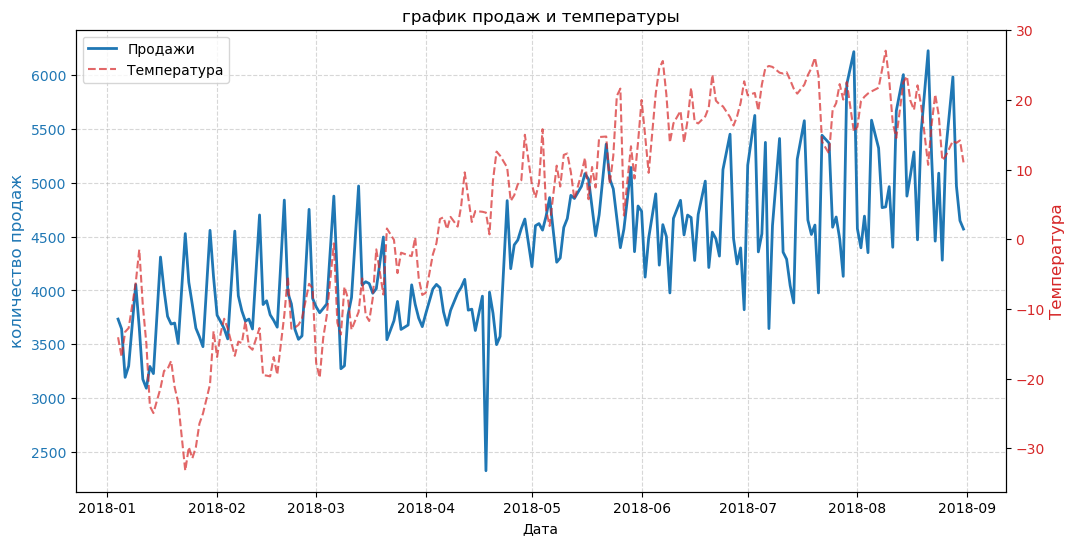

In [25]:
fig, ax1 = plt.subplots(figsize = (12, 6))
color_sales = 'tab:blue'
ax1.set_xlabel('Дата')
ax1. set_ylabel('количество продаж', color = color_sales, fontsize = 12)
ax1.plot(merged_df['Дата'], merged_df['Количество'], color = color_sales, label='Продажи', linewidth = 2)
ax1.tick_params(axis='y', labelcolor = color_sales)
ax1.grid(True, linestyle = '--', alpha = 0.5)

ax2 = ax1.twinx()
color_temp = 'tab:red'
ax2.set_ylabel('Температура', color = color_temp, fontsize=12)
ax2.plot(merged_df['Дата'], merged_df['T'], color = color_temp, label='Температура', linestyle='--', alpha=0.7)
ax2.tick_params(axis='y', labelcolor = color_temp)

plt.title('график продаж и температуры')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')
plt.show()